# Review EDA Findings from Data Science Team

Tahap ini bertujuan memahami dataset secara menyeluruh sebelum menentukan feature engineering.

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [164]:
df = pd.read_csv('/content/hospital_dataset_final_v2.csv')

In [165]:
df.head()

,visit_id,date,patient_id,age,gender,insurance,patient_type,dept_id,dept_name,doctor_id,doctor_name,arrival_time,registration_time,service_start,service_end,service_duration,wait_time,day_name,is_peak
0,V-10000,2025-10-01,PAT-1178,12,M,BPJS,Returning,DP-01,Poli Umum,DOC-101,Dr. Andi Santoso,08:11,08:49,08:49,09:01,12,38.0,Wednesday,0
1,V-10001,2025-10-01,PAT-1123,27,F,Private,New,DP-03,Poli Anak,DOC-103,Dr. Budi Hermawan,09:05,09:11,09:11,09:21,10,6.0,Wednesday,1
2,V-10002,2025-10-01,PAT-1240,37,F,Private,New,DP-01,Poli Umum,DOC-101,Dr. Andi Santoso,10:58,11:03,11:03,11:23,20,5.0,Wednesday,1
3,V-10003,2025-10-01,PAT-1182,56,F,BPJS,New,DP-04,Poli Jantung,DOC-104,Dr. Dewi Lestari,11:03,11:36,11:36,12:04,28,33.0,Wednesday,1
4,V-10004,2025-10-01,PAT-1102,41,M,BPJS,Returning,DP-03,Poli Anak,DOC-103,Dr. Budi Hermawan,14:10,14:31,14:31,14:55,24,21.0,Wednesday,1


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11168 entries, 0 to 11167
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   visit_id           11168 non-null  object 
 1   date               11168 non-null  object 
 2   patient_id         11168 non-null  object 
 3   age                11168 non-null  int64  
 4   gender             11168 non-null  object 
 5   insurance          11168 non-null  object 
 6   patient_type       11168 non-null  object 
 7   dept_id            11168 non-null  object 
 8   dept_name          11168 non-null  object 
 9   doctor_id          11168 non-null  object 
 10  doctor_name        11168 non-null  object 
 11  arrival_time       11168 non-null  object 
 12  registration_time  11168 non-null  object 
 13  service_start      11168 non-null  object 
 14  service_end        11168 non-null  object 
 15  service_duration   11168 non-null  int64  
 16  wait_time          111

In [167]:
df.isnull().sum()

,0
visit_id,0
date,0
patient_id,0
age,0
gender,0
insurance,0
patient_type,0
dept_id,0
dept_name,0
doctor_id,0


In [168]:
df.describe()

,age,service_duration,wait_time,is_peak
count,11168.000000,11168.000000,11168.000000,11168.000000
mean,40.031160,22.590347,256.320201,0.846347
std,23.465087,8.508367,197.825275,0.360632
min,1.000000,7.000000,5.000000,0.000000
25%,19.000000,16.000000,97.275000,1.000000
50%,39.000000,22.000000,227.400000,1.000000
75%,60.000000,30.000000,366.512500,1.000000
max,84.000000,39.000000,1469.000000,1.000000


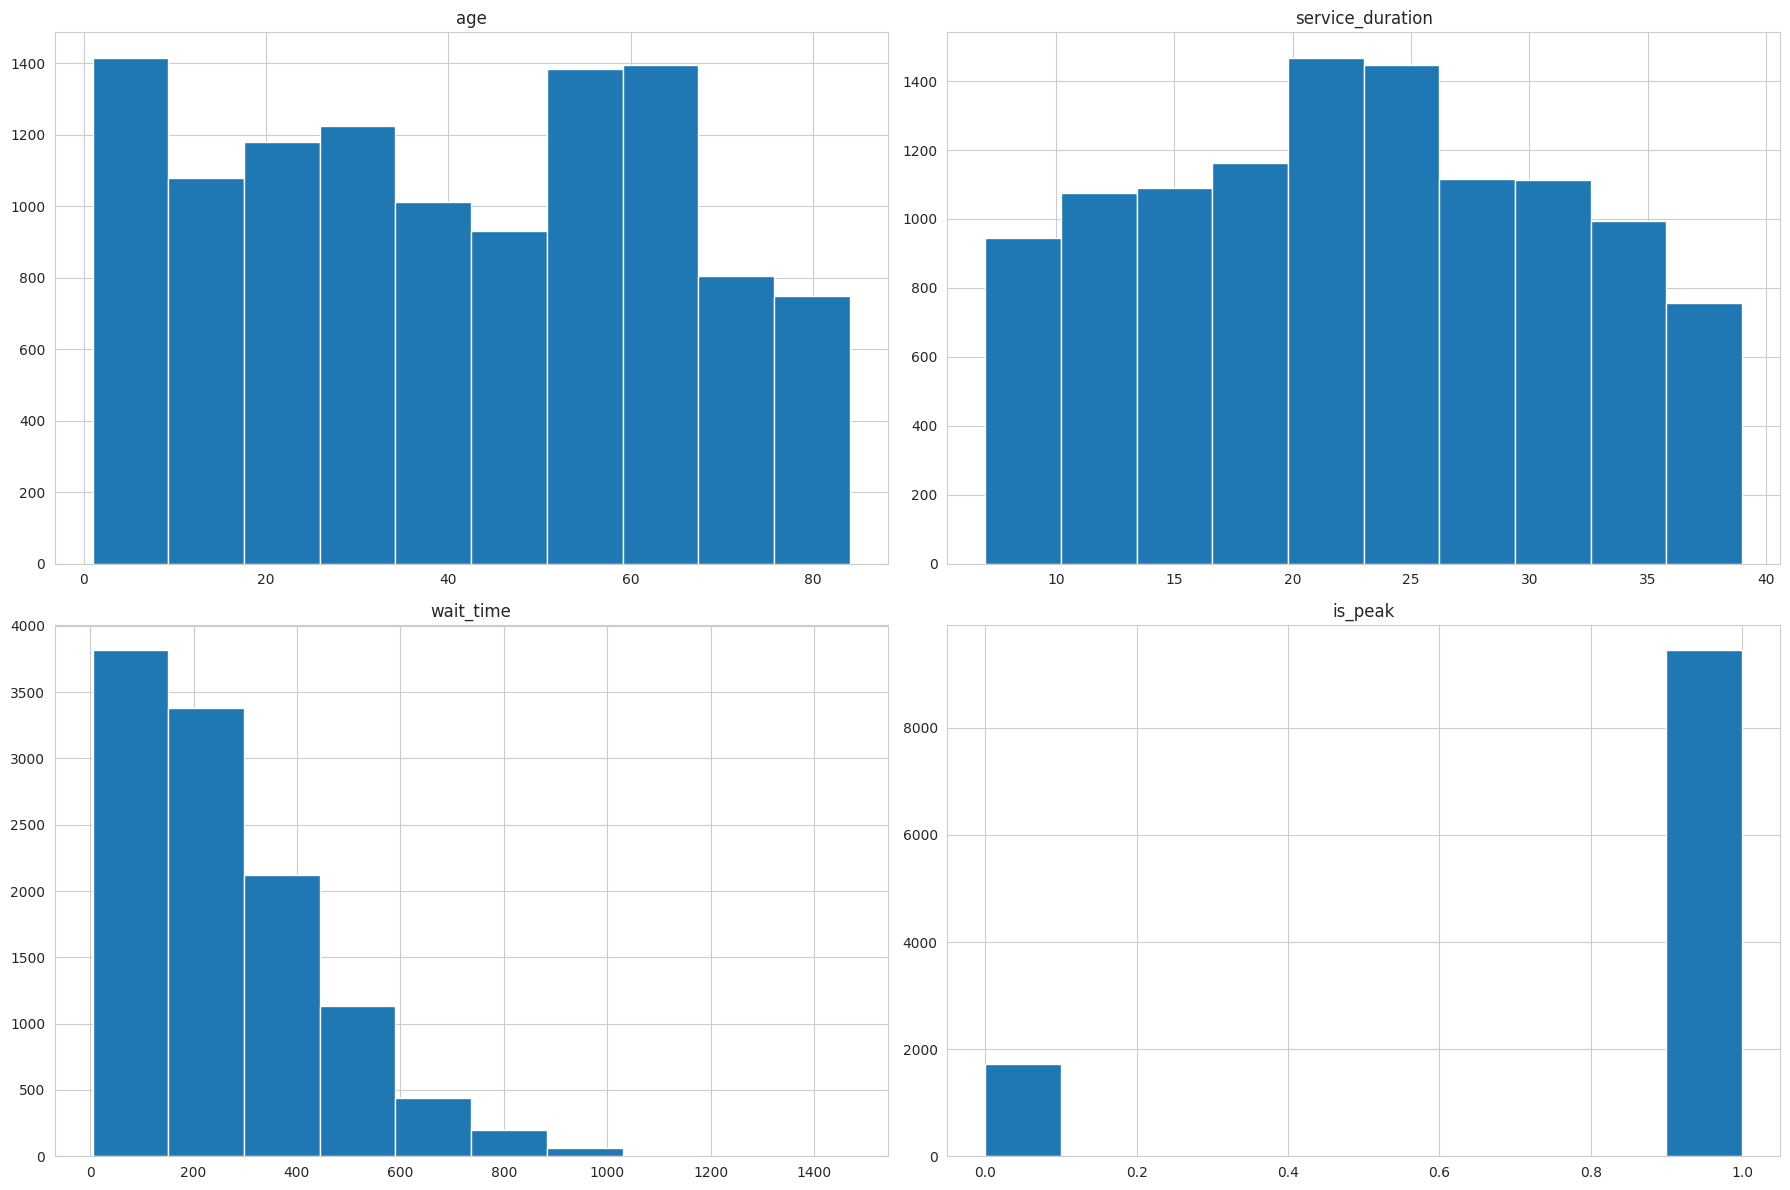

In [169]:
df.hist(figsize=(18,12))
plt.tight_layout()
plt.show()

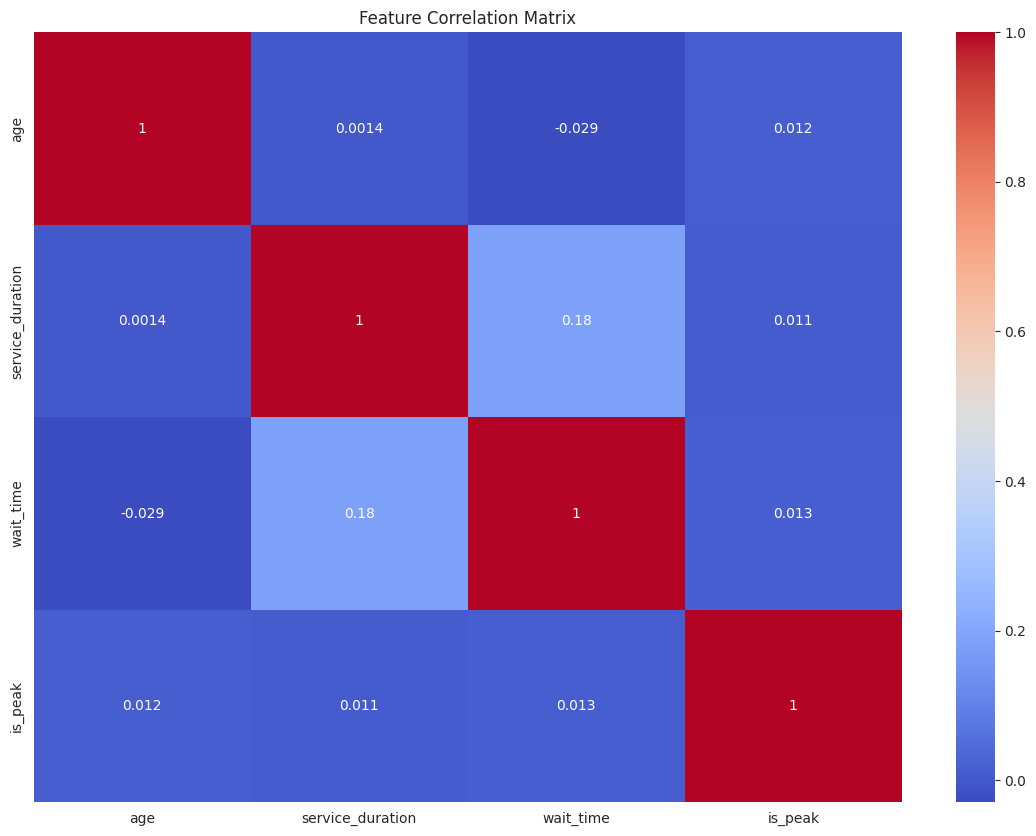

In [170]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [171]:
df['wait_time']

,wait_time
0,38.00
1,6.00
2,5.00
3,33.00
4,21.00
...,...
11163,344.00
11164,511.00
11165,537.00
11166,265.65


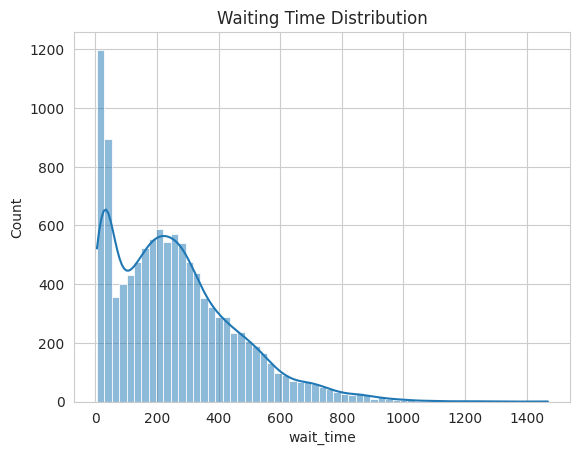

In [172]:
sns.histplot(df['wait_time'], kde=True)
plt.title("Waiting Time Distribution")
plt.show()

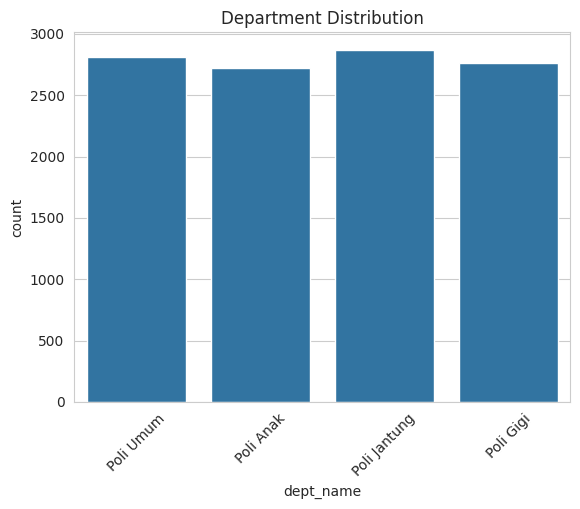

In [173]:
sns.countplot(x='dept_name', data=df)
plt.xticks(rotation=45)
plt.title("Department Distribution")
plt.show()

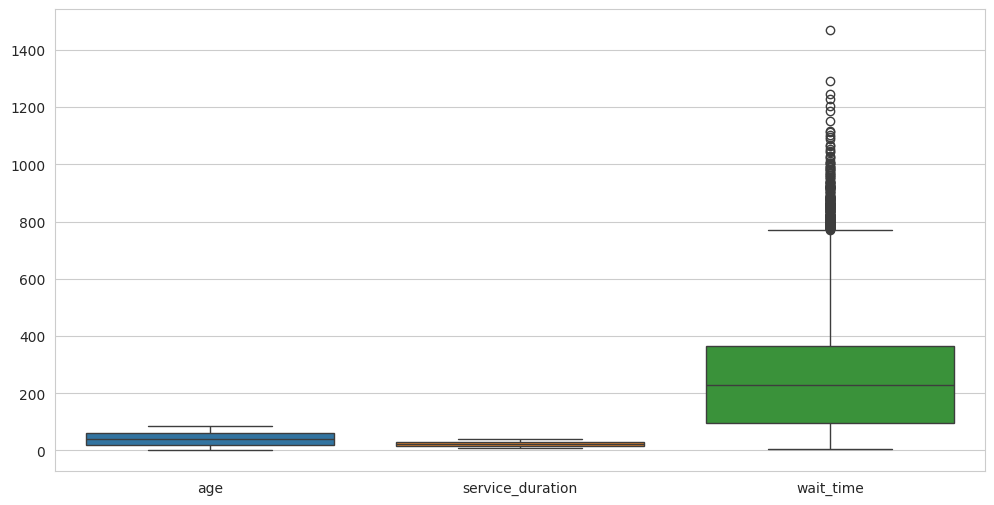

In [174]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['age','service_duration','wait_time']])
plt.show()

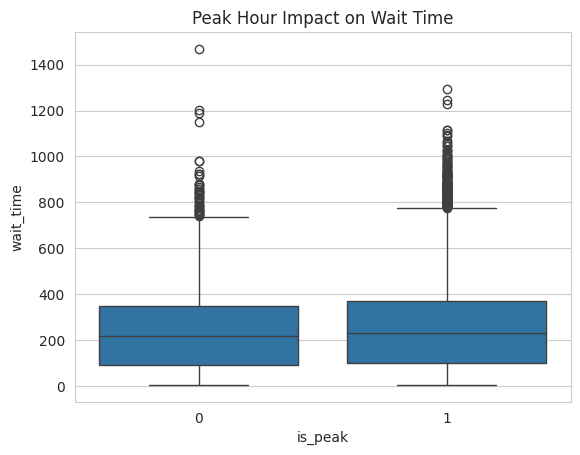

In [175]:
sns.boxplot(x='is_peak', y='wait_time', data=df)
plt.title("Peak Hour Impact on Wait Time")
plt.show()

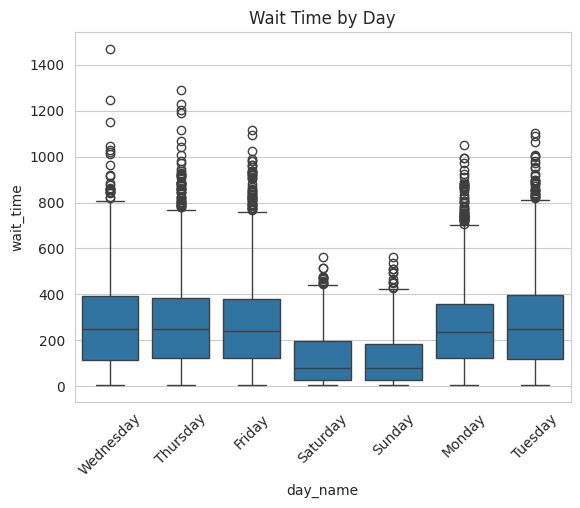

In [176]:
sns.boxplot(x='day_name', y='wait_time', data=df)
plt.xticks(rotation=45)
plt.title("Wait Time by Day")
plt.show()

In [177]:
df['doctor_name'].value_counts()

,count
doctor_name,
Dr. Dewi Lestari,2870
Dr. Andi Santoso,2813
Dr. Siti Aminah,2760
Dr. Budi Hermawan,2725


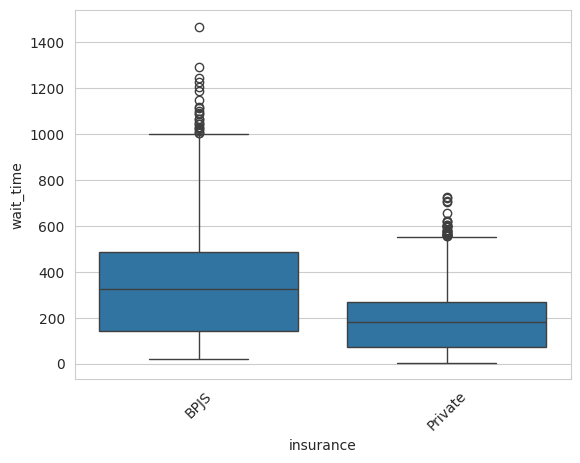

In [178]:
sns.boxplot(x='insurance', y='wait_time', data=df)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_979/3027138251.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['arrival_hour'] = pd.to_datetime(df['arrival_time']).dt.hour


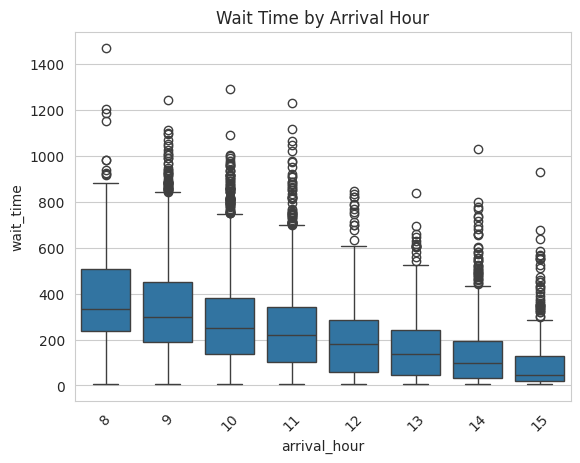

In [179]:
df['arrival_hour'] = pd.to_datetime(df['arrival_time']).dt.hour

sns.boxplot(x='arrival_hour', y='wait_time', data=df)
plt.xticks(rotation=45)
plt.title("Wait Time by Arrival Hour")
plt.show()

In [180]:
df.groupby('dept_name')['wait_time'].mean().sort_values()

,wait_time
dept_name,
Poli Umum,212.669143
Poli Anak,215.082954
Poli Gigi,281.743351
Poli Jantung,313.809408


In [181]:
df.groupby('doctor_name')['wait_time'].mean().sort_values()

,wait_time
doctor_name,
Dr. Andi Santoso,212.669143
Dr. Budi Hermawan,215.082954
Dr. Siti Aminah,281.743351
Dr. Dewi Lestari,313.809408


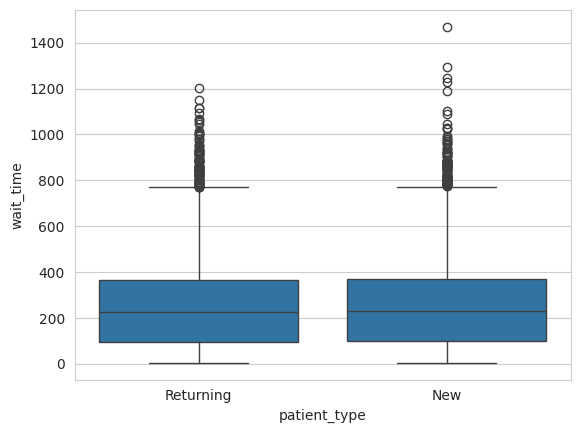

In [182]:
sns.boxplot(x='patient_type', y='wait_time', data=df)
plt.show()

# Temporal Feature Engineering

Temporal feature engineering dilakukan untuk menangkap pola antrean berdasarkan waktu kedatangan pasien. Fitur seperti arrival hour, hari kunjungan, bulan, dan minggu diekstraksi dari data waktu asli. Selain itu, cyclical encoding diterapkan pada fitur jam untuk merepresentasikan pola waktu secara kontinu sehingga model dapat memahami hubungan antar jam secara lebih akurat.

In [183]:
df['date'] = pd.to_datetime(df['date'])
df['arrival_time'] = pd.to_datetime(df['arrival_time'], format='%H:%M')

In [184]:
df['arrival_hour'] = df['arrival_time'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

In [185]:
df['hour_sin'] = np.sin(2 * np.pi * df['arrival_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['arrival_hour'] / 24)

In [186]:
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

In [187]:
df[['arrival_hour','day_of_week','month','week_of_year',
    'hour_sin','hour_cos']].head()

,arrival_hour,day_of_week,month,week_of_year,hour_sin,hour_cos
0,8,2,10,40,0.866025,-0.500000
1,9,2,10,40,0.707107,-0.707107
2,10,2,10,40,0.500000,-0.866025
3,11,2,10,40,0.258819,-0.965926
4,14,2,10,40,-0.500000,-0.866025


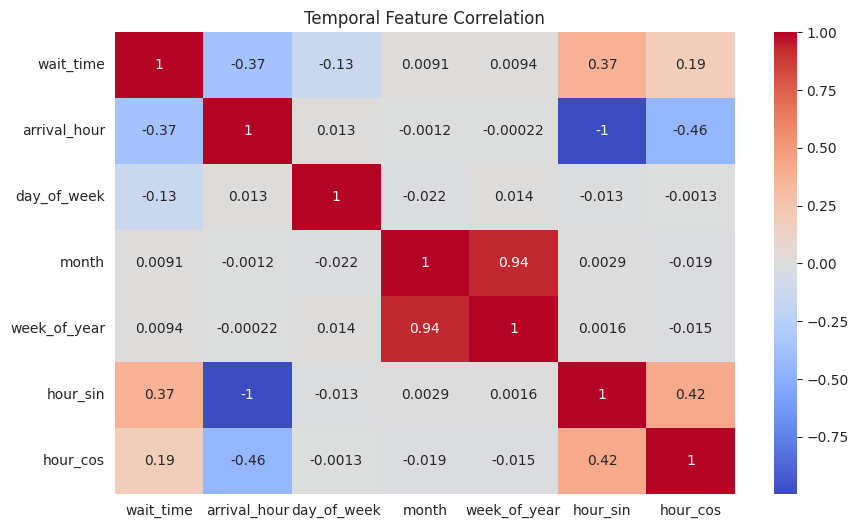

In [188]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['wait_time','arrival_hour','day_of_week','month',
        'week_of_year','hour_sin','hour_cos']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Temporal Feature Correlation")
plt.show()

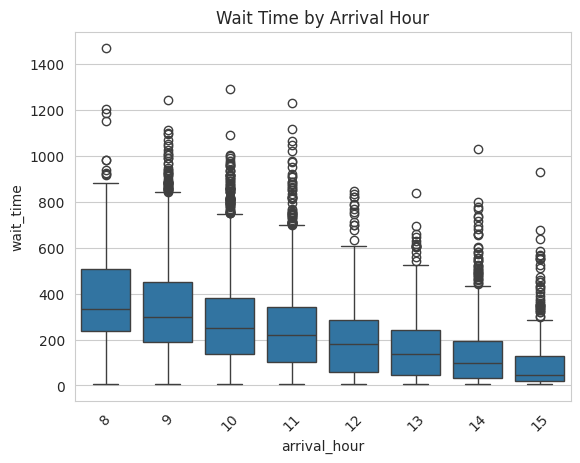

In [189]:
sns.boxplot(x='arrival_hour', y='wait_time', data=df)
plt.xticks(rotation=45)
plt.title("Wait Time by Arrival Hour")
plt.show()

# Queue-Based Feature Design

Queue-based feature engineering dilakukan untuk menangkap dinamika operasional rumah sakit secara real-time, termasuk kepadatan antrean per jam, beban poli, beban dokter, dan tekanan layanan. Fitur ini membantu model memahami faktor sistemik yang memengaruhi waktu tunggu pasien selain karakteristik individu pasien.

In [190]:
df['queue_per_hour'] = df.groupby(
    ['date', 'arrival_hour']
)['visit_id'].transform('count')

In [191]:
df = df.sort_values(['date', 'arrival_hour'])

df['queue_trend'] = df.groupby('date')['queue_per_hour'].diff().fillna(0)

In [192]:
df['dept_queue_load'] = df.groupby(
    ['date', 'dept_name']
)['visit_id'].transform('count')

In [193]:
df['doctor_daily_load'] = df.groupby(
    ['date', 'doctor_name']
)['visit_id'].transform('count')

In [194]:
df['dept_avg_wait'] = df.groupby('dept_name')['wait_time'].transform('mean')
df['doctor_avg_wait'] = df.groupby('doctor_name')['wait_time'].transform('mean')

df['doctor_efficiency'] = (
    df['doctor_daily_load'] / (df['doctor_avg_wait'] + 1)
)

In [195]:
df['dept_avg_wait'] = df.groupby(
    'dept_name'
)['wait_time'].transform('mean')

In [196]:
df['doctor_avg_wait'] = df.groupby(
    'doctor_name'
)['wait_time'].transform('mean')

In [197]:
df['service_pressure'] = (
    df['queue_per_hour'] * df['service_duration']
)

In [198]:
df['queue_velocity'] = df['queue_per_hour'] / (df['service_duration'] + 1)

In [199]:
df[[
    'queue_per_hour',
    'dept_queue_load',
    'doctor_daily_load',
    'doctor_efficiency',
    'dept_avg_wait',
    'doctor_avg_wait',
    'service_pressure'
]].head()

,queue_per_hour,dept_queue_load,doctor_daily_load,doctor_efficiency,dept_avg_wait,doctor_avg_wait,service_pressure
0,2,17,17,0.079562,212.669143,212.669143,24
9,2,20,20,0.070736,281.743351,281.743351,62
1,19,24,24,0.111068,215.082954,215.082954,190
8,19,17,17,0.079562,212.669143,212.669143,399
12,19,24,24,0.111068,215.082954,215.082954,437


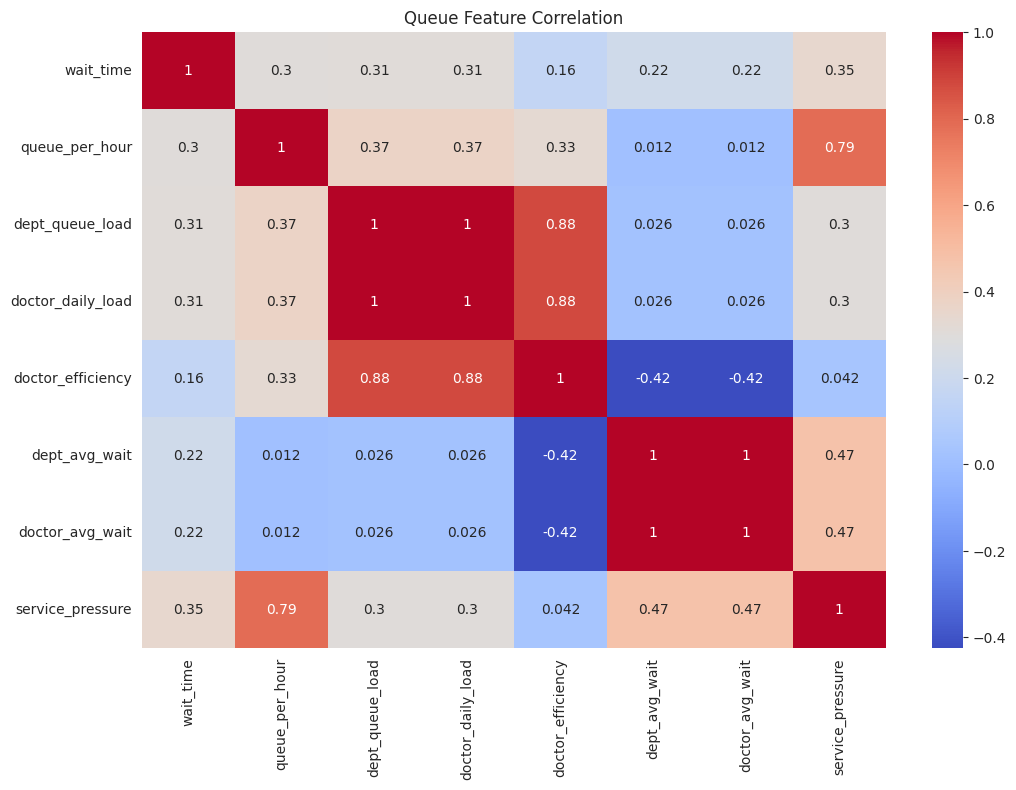

In [200]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[[
        'wait_time',
        'queue_per_hour',
        'dept_queue_load',
        'doctor_daily_load',
        'doctor_efficiency',
        'dept_avg_wait',
        'doctor_avg_wait',
        'service_pressure'
    ]].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Queue Feature Correlation")
plt.show()

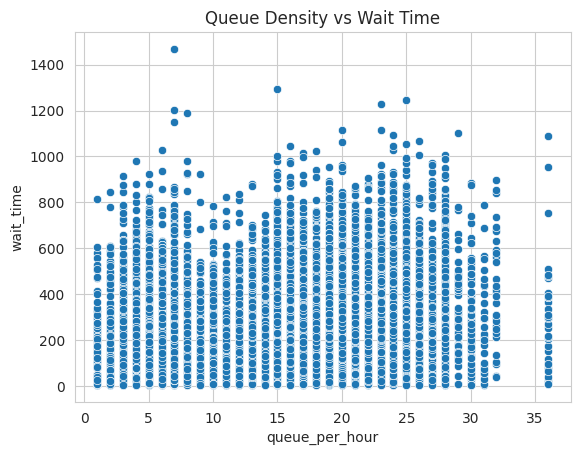

In [201]:
sns.scatterplot(
    x='queue_per_hour',
    y='wait_time',
    data=df
)

plt.title("Queue Density vs Wait Time")
plt.show()

# Doctor & Department Feature Validation
Doctor and department validation dilakukan untuk mengevaluasi pengaruh variasi performa tenaga medis dan unit layanan terhadap waktu tunggu pasien. Analisis menunjukkan bahwa beban dokter, rata-rata waktu tunggu dokter, kepadatan departemen, serta rata-rata wait time per poli merupakan faktor penting yang berkontribusi terhadap prediksi antrean.

In [202]:
doctor_wait = df.groupby('doctor_name')['wait_time'].mean().sort_values()

print(doctor_wait)

doctor_name
Dr. Andi Santoso     212.669143
Dr. Budi Hermawan    215.082954
Dr. Siti Aminah      281.743351
Dr. Dewi Lestari     313.809408
Name: wait_time, dtype: float64


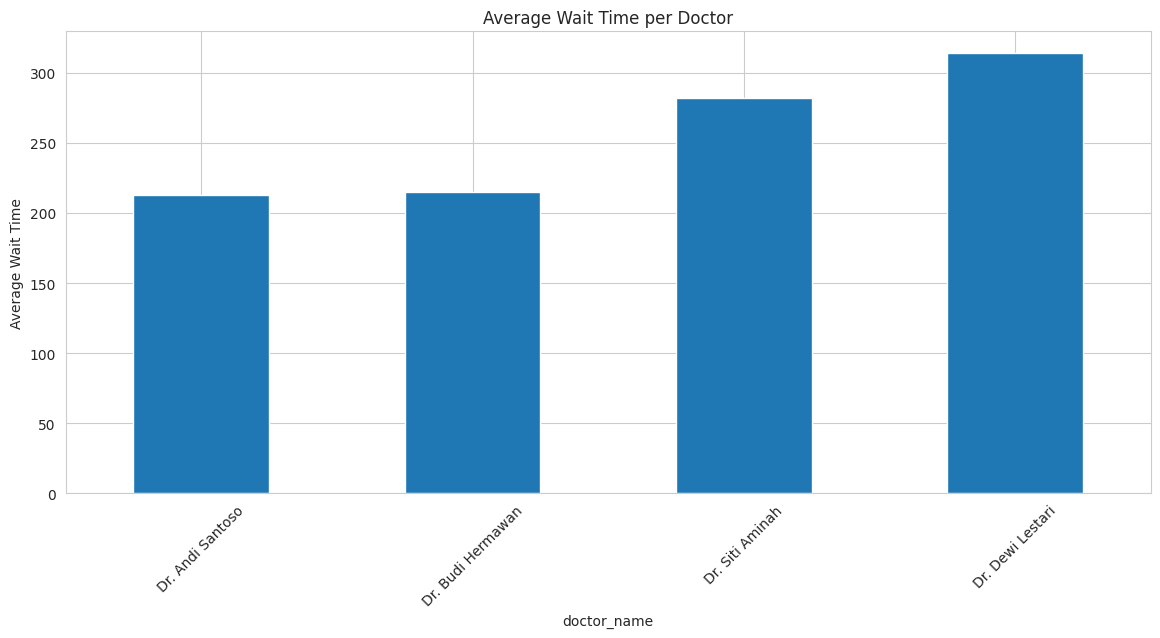

In [203]:
plt.figure(figsize=(14,6))

doctor_wait.plot(kind='bar')

plt.title("Average Wait Time per Doctor")
plt.ylabel("Average Wait Time")
plt.xticks(rotation=45)

plt.show()

In [204]:
dept_wait = df.groupby('dept_name')['wait_time'].mean().sort_values()

print(dept_wait)

dept_name
Poli Umum       212.669143
Poli Anak       215.082954
Poli Gigi       281.743351
Poli Jantung    313.809408
Name: wait_time, dtype: float64


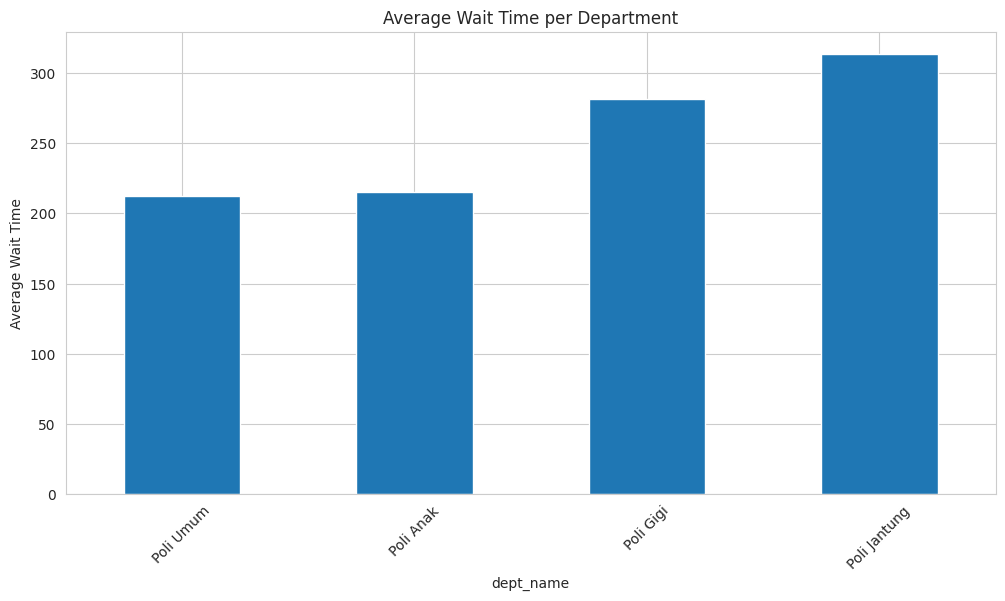

In [205]:
plt.figure(figsize=(12,6))

dept_wait.plot(kind='bar')

plt.title("Average Wait Time per Department")
plt.ylabel("Average Wait Time")
plt.xticks(rotation=45)

plt.show()

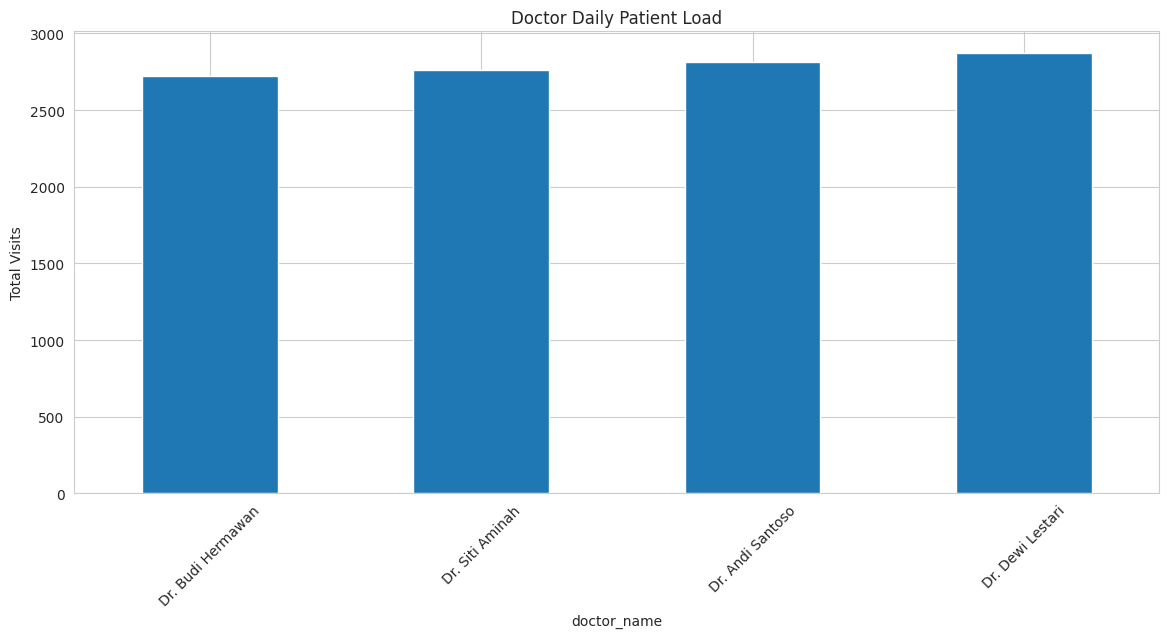

In [206]:
doctor_load = df.groupby('doctor_name')['visit_id'].count().sort_values()

plt.figure(figsize=(14,6))

doctor_load.plot(kind='bar')

plt.title("Doctor Daily Patient Load")
plt.ylabel("Total Visits")
plt.xticks(rotation=45)

plt.show()

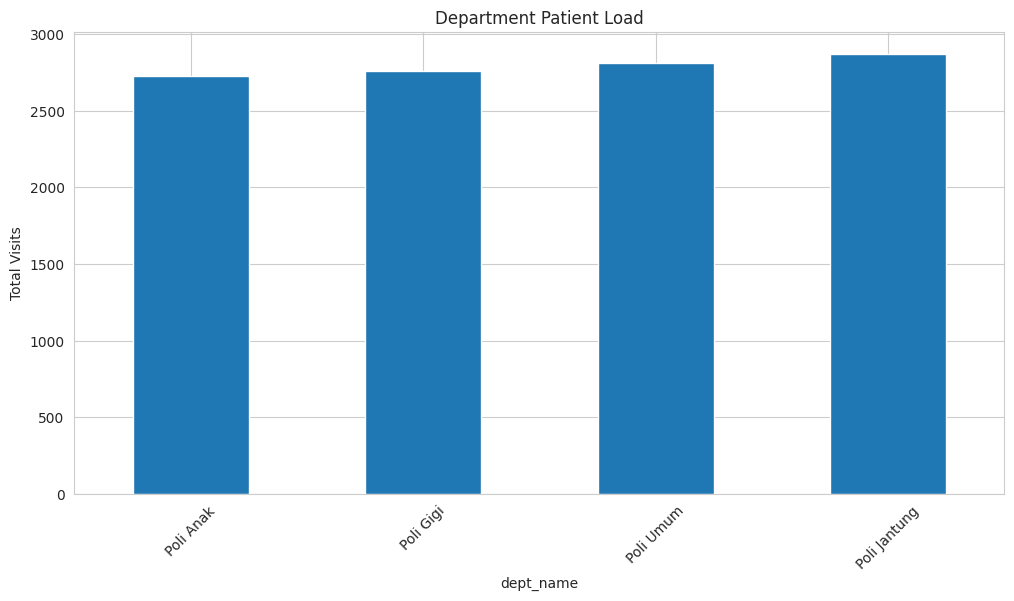

In [207]:
dept_load = df.groupby('dept_name')['visit_id'].count().sort_values()

plt.figure(figsize=(12,6))

dept_load.plot(kind='bar')

plt.title("Department Patient Load")
plt.ylabel("Total Visits")
plt.xticks(rotation=45)

plt.show()

In [208]:
df['dept_service_capacity'] = df.groupby(
    'dept_name'
)['service_duration'].transform('mean')

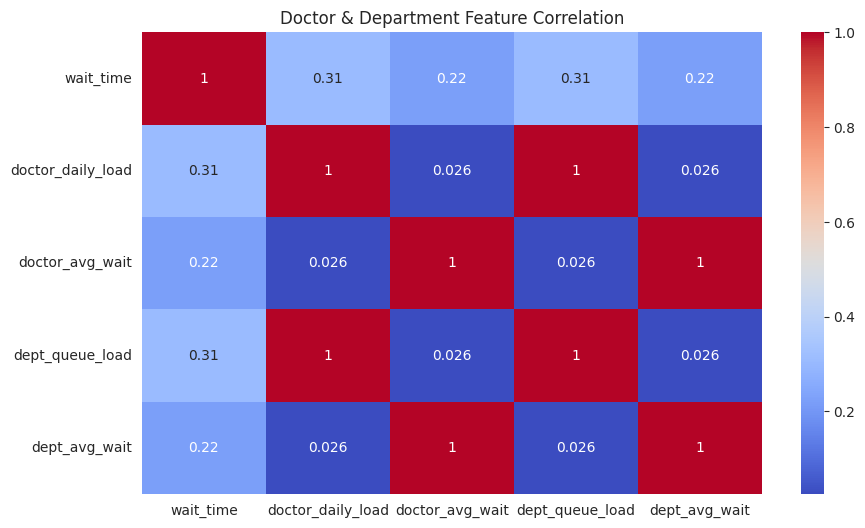

In [209]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[[
        'wait_time',
        'doctor_daily_load',
        'doctor_avg_wait',
        'dept_queue_load',
        'dept_avg_wait'
    ]].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Doctor & Department Feature Correlation")

plt.show()

# Full Feature Engineering Pipeline Preparation
Full feature engineering pipeline dilakukan dengan memilih fitur-fitur paling relevan berdasarkan hasil EDA, temporal analysis, queue dynamics, serta validasi operasional dokter dan departemen. Data kategorikal diubah menggunakan label encoding, sementara fitur numerik dinormalisasi menggunakan StandardScaler agar model deep learning dapat belajar secara optimal.

In [210]:
selected_features = [
    'age',
    'gender',
    'insurance',
    'patient_type',
    'dept_name',
    'doctor_name',
    'service_duration',
    'is_peak',
    'arrival_hour',
    'day_of_week',
    'month',
    'week_of_year',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    'queue_per_hour',
    'queue_trend',
    'queue_velocity',
    'dept_queue_load',
    'doctor_daily_load',
    'dept_avg_wait',
    'doctor_avg_wait',
    'dept_service_capacity',
    'doctor_efficiency',
    'service_pressure'
]

X = df[selected_features].copy()
y = df['wait_time']

In [211]:
categorical_cols = [
    'gender',
    'insurance',
    'patient_type',
    'dept_name',
    'doctor_name'
]

In [212]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [213]:
X.head()

,age,gender,insurance,patient_type,dept_name,doctor_name,service_duration,is_peak,arrival_hour,day_of_week,...,queue_per_hour,queue_trend,queue_velocity,dept_queue_load,doctor_daily_load,dept_avg_wait,doctor_avg_wait,dept_service_capacity,doctor_efficiency,service_pressure
0,12,1,0,1,3,0,12,0,8,2,...,2,0.0,0.153846,17,17,212.669143,212.669143,14.066122,0.079562,24
9,9,0,0,0,1,3,31,0,8,2,...,2,0.0,0.062500,20,20,281.743351,281.743351,27.060145,0.070736,62
1,27,0,1,0,0,1,10,1,9,2,...,19,17.0,1.727273,24,24,215.082954,215.082954,16.968807,0.111068,190
8,63,1,1,1,3,0,21,1,9,2,...,19,0.0,0.863636,17,17,212.669143,212.669143,14.066122,0.079562,399
12,78,0,1,1,0,1,23,1,9,2,...,19,0.0,0.791667,24,24,215.082954,215.082954,16.968807,0.111068,437


In [214]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [215]:
print("Feature Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Feature Shape: (11168, 26)
Target Shape: (11168,)


In [216]:
import joblib

joblib.dump(scaler, 'scaler.save')
joblib.dump(label_encoders, 'label_encoders.save')

['label_encoders.save']

# Feature Documentation

| Feature | Type | Description |
|--------|------|-------------|
| arrival_hour | Temporal | Jam kedatangan pasien |
| day_of_week | Temporal | Hari kunjungan |
| hour_sin/hour_cos | Cyclical | Representasi siklus jam |
| queue_per_hour | Queue | Jumlah pasien per jam |
| queue_trend | Queue | Perubahan antrean |
| queue_velocity | Queue | Kecepatan layanan |
| dept_queue_load | Department | Beban poli |
| dept_avg_wait | Department | Rata-rata wait time poli |
| dept_service_capacity | Department | Kapasitas layanan poli |
| doctor_daily_load | Doctor | Beban dokter |
| doctor_avg_wait | Doctor | Rata-rata wait time dokter |
| doctor_efficiency | Doctor | Efisiensi dokter |
| service_pressure | Operational | Tekanan operasional |